##### Import statements:

In [1]:
import os
import pathlib
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib import colormaps
from analysis_metadata.analysis_metadata import Metadata, increment_dir_name, write_metadata

##### Define inputs, parameters:

In [71]:
# Input file:
input_path = os.path.join('/', 'mnt', 'smb', 'locker', 'issa-locker', 'users', 'Dan', 'code', 'ws', 'results', 'run845', 'tngl_pred.pickle')
input_dir = os.path.split(input_path)[0]

# Output parameters:
save_output = True
base_dir_name = 'ps_v_pr'

##### Load previously-saved results:

In [72]:
tngl_evo_pred_results = pickle.load(open(input_path, 'rb'))
geo_df = tngl_evo_pred_results['geo_df'] 
loss_df = tngl_evo_pred_results['ae_df']

##### Find aymptotic participation ratio for all entangler models:

In [73]:
tngl_loss_df = loss_df[loss_df.mdl_type=='autoencoder']
max_epoch_tngl_df = tngl_loss_df[['tngl_mdl_id', 'epoch']].groupby('tngl_mdl_id').apply(lambda x : np.max(x.epoch)).reset_index(name='epoch')
tngl_loss_pr_df = pd.merge(tngl_loss_df, max_epoch_tngl_df, on=['tngl_mdl_id', 'epoch'])

##### Find paralellism score for entangler models:

In [75]:
geo_df_tngl = geo_df[geo_df.mdl_type=='autoencoder']
geo_df_tngl_hidden = geo_df_tngl[geo_df_tngl.layer=='hidden']
geo_df_tngl_hidden_final = pd.merge(geo_df_tngl_hidden, max_epoch_tngl_df, on=['tngl_mdl_id', 'epoch'])
ps_tngl_df = geo_df_tngl_hidden_final[['tngl_mdl_id', 'parallelism']].groupby('tngl_mdl_id').mean()
ps_tngl_df = ps_tngl_df.rename(columns={'parallelism':'parallelism_tngl'}) 

##### Find parallelism score for prediction models:

In [51]:
pred_loss_df = loss_df[loss_df.mdl_type=='prediction']
max_epoch_pred_df = pred_loss_df[['tngl_mdl_id', 'epoch']].groupby('tngl_mdl_id').apply(lambda x : np.max(x.epoch)).reset_index(name='epoch')

geo_df_pred = geo_df[geo_df.mdl_type=='prediction']
geo_df_pred_hidden = geo_df_pred[geo_df_pred.layer=='hidden']
geo_df_pred_hidden_final = pd.merge(geo_df_pred_hidden, max_epoch_pred_df, on=['tngl_mdl_id', 'epoch'])
ps_pred_df = geo_df_pred_hidden_final[['tngl_mdl_id', 'pred_mdl_id', 'parallelism']].groupby(['tngl_mdl_id', 'pred_mdl_id']).mean().reset_index()
ps_pred_df = ps_pred_df.rename(columns={'parallelism':'parallelism_pred'}) 

##### Find input parallelism:

In [99]:
geo_df_inpt = geo_df_pred[np.array(geo_df_pred.layer=='inpt') & np.array(geo_df_pred.mdl_type=='prediction')]
inpt_parallelism = np.mean(geo_df_inpt.parallelism)
#geo_df_inpt[['tngl_mdl_id', 'mdl_type', 'epoch', 'dichotomy_idx', 'parallelism']]

##### Merge participation ratio, entangler parallelism, and prediction model parallelism results:

In [52]:
ps_df = pd.merge(tngl_loss_pr_df[['tngl_mdl_id', 'loss_pr']], ps_tngl_df, on=['tngl_mdl_id'])
ps_df = pd.merge(ps_df, ps_pred_df, on=['tngl_mdl_id'])

##### Generate scatterplot of parallelism score vs. participation ratio, separate points for entangler and prediction model: 

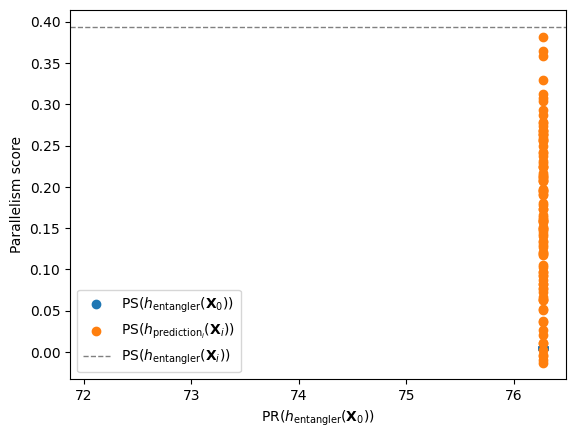

In [103]:
fig0, ax0 = plt.subplots()

# Scatter data:
tngl_leg_str = r'$h_{\text{entangler}}(\mathbf{X}_0)$'
pred_leg_str = r'$h_{\text{prediction}_i}(\mathbf{X}_i)$'
plt.scatter(ps_df.loss_pr, ps_df.parallelism_tngl, label=tngl_leg_str)
plt.scatter(ps_df.loss_pr, ps_df.parallelism_pred, label=pred_leg_str)

# Reference line for input parallelism:
xl = plt.xlim()
#inpt_str = 'input'
inpt_str = r'$\text{PS}(h_{\text{entangler}}(\mathbf{X}_i))$'
plt.axline([xl[0], inpt_parallelism], slope=0, color='gray', linewidth=1, linestyle='--', label=inpt_str)

# Add axis labels, title:
ylabel = 'Parallelism score'
xlabel = r'$\text{PR}(h_\text{entangler}(\mathbf{X}_0))$'
plt.ylabel(ylabel)
plt.xlabel(xlabel)
plt.legend()

##### Generate scatterplot of prediction model parallelism score vs entangler model parallelism score:

Text(0.5, 0, '$\\text{PS}(h_\\text{entangler}(\\mathbf{X}_0))$')

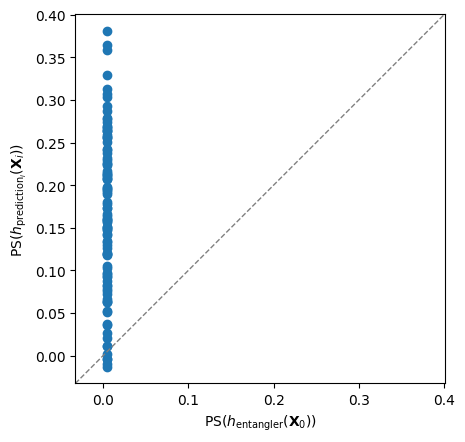

In [46]:
fig1, ax1 = plt.subplots()

# Scatter data:
plt.scatter(ps_df.parallelism_tngl, ps_df.parallelism_pred)

# Set axis limits equal:
xl = plt.xlim()
yl = plt.ylim()
minmin = min([xl[0], yl[0]])
maxmax = max([xl[1], yl[1]])
lims = [minmin, maxmax]
plt.xlim(lims)
plt.ylim(lims)
ax1.set_aspect('equal')
plt.axline([0,0], slope=1, color='gray', linewidth=1, linestyle='--')

# Axis labels, etc:
xstr = r'$\text{PS}(h_{\text{prediction}_i}(\mathbf{X}_i))$'
ystr = r'$\text{PS}(h_\text{entangler}(\mathbf{X}_0))$'
plt.ylabel(xstr)
plt.xlabel(ystr)